# IMDB Sentiment Model for FastAPI Integration

Notebook ini menyiapkan model klasifikasi sentimen `positive` vs `negative` dari dataset IMDB dan mengekspor artefak yang siap dipakai dari FastAPI.

Target utama:
- preprocessing yang konsisten
- evaluasi model yang jelas
- artefak `joblib` yang siap diload oleh API
- contoh format output prediksi

In [1]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

from sentiment_utils import clean_text

In [2]:
DATA_PATH = Path('IMDB Dataset.csv')
ARTIFACT_DIR = Path('artifacts')
ARTIFACT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.2

In [3]:
df = pd.read_csv(DATA_PATH)
df['clean_review'] = df['review'].map(clean_text)

print('Shape:', df.shape)
print('\nLabel distribution:')
print(df['sentiment'].value_counts())
display(df.head())

Shape: (50000, 3)

Label distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,One of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,positive,A wonderful little production. The filming tec...
2,I thought this was a wonderful way to spend ti...,positive,I thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,negative,Basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,"Petter Mattei's ""Love in the Time of Money"" is..."


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review'],
    df['sentiment'],
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df['sentiment'],
)

print('Train size:', len(X_train))
print('Test size :', len(X_test))

Train size: 40000
Test size : 10000


In [5]:
common_tfidf = dict(
    preprocessor=clean_text,
    lowercase=True,
    strip_accents='unicode',
    stop_words='english',
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.9,
    sublinear_tf=True,
)

candidate_models = {
    'multinomial_nb': MultinomialNB(),
    'logistic_regression': LogisticRegression(max_iter=2000, solver='liblinear'),
    'linear_svc': LinearSVC(),
}

benchmark_rows = []

for model_name, estimator in candidate_models.items():
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(**common_tfidf)),
        ('model', estimator),
    ])
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    benchmark_rows.append({
        'model': model_name,
        'accuracy': accuracy_score(y_test, predictions),
        'f1_positive': f1_score(y_test, predictions, pos_label='positive'),
    })

benchmark_df = pd.DataFrame(benchmark_rows).sort_values(['accuracy', 'f1_positive'], ascending=False)
benchmark_df

,model,accuracy,f1_positive
2,linear_svc,0.9123,0.912901
1,logistic_regression,0.9030,0.904017
0,multinomial_nb,0.8864,0.886468


## Deployment Choice

Untuk deployment API, saya sarankan `LogisticRegression` sebagai model utama.

Alasannya:
- akurasinya biasanya sangat kompetitif di IMDB
- inference cepat
- mendukung `predict_proba()` sehingga API bisa mengembalikan confidence score

Accuracy: 0.9030

Classification Report:
              precision    recall  f1-score   support

    negative       0.91      0.89      0.90      5000
    positive       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



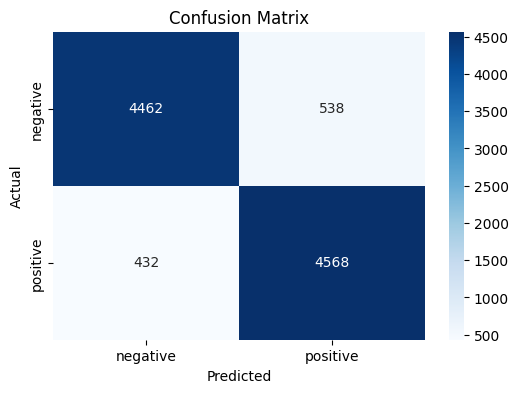

In [6]:
deployment_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(**common_tfidf)),
    ('model', LogisticRegression(max_iter=2000, solver='liblinear')),
])

deployment_pipeline.fit(X_train, y_train)
y_pred = deployment_pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)
cm = confusion_matrix(y_test, y_pred, labels=['negative', 'positive'])

print(f'Accuracy: {accuracy:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['negative', 'positive'],
    yticklabels=['negative', 'positive'],
)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [7]:
def predict_sentiment(text: str) -> dict:
    probabilities = deployment_pipeline.predict_proba([text])[0]
    labels = deployment_pipeline.classes_.tolist()
    scores = {label: float(score) for label, score in zip(labels, probabilities)}
    predicted_label = max(scores, key=scores.get)
    return {
        'label': predicted_label,
        'confidence': round(scores[predicted_label], 4),
        'scores': {label: round(score, 4) for label, score in scores.items()},
        'is_positive': predicted_label == 'positive',
    }

sample_review = 'This movie was surprisingly heartfelt, funny, and beautifully acted.'
predict_sentiment(sample_review)

{'label': 'positive',
 'confidence': 0.8936,
 'scores': {'negative': 0.1064, 'positive': 0.8936},
 'is_positive': True}

In [8]:
model_path = ARTIFACT_DIR / 'imdb_sentiment_pipeline.joblib'
metrics_path = ARTIFACT_DIR / 'imdb_sentiment_metrics.json'

joblib.dump(deployment_pipeline, model_path)

metrics_payload = {
    'model_name': 'tfidf_logistic_regression',
    'accuracy': round(float(accuracy), 6),
    'macro_avg_f1': round(float(report['macro avg']['f1-score']), 6),
    'weighted_avg_f1': round(float(report['weighted avg']['f1-score']), 6),
    'labels': deployment_pipeline.classes_.tolist(),
    'test_size': TEST_SIZE,
    'random_state': RANDOM_STATE,
}

metrics_path.write_text(json.dumps(metrics_payload, indent=2))

print('Saved model  :', model_path)
print('Saved metrics:', metrics_path)
metrics_payload

Saved model  : artifacts/imdb_sentiment_pipeline.joblib
Saved metrics: artifacts/imdb_sentiment_metrics.json


{'model_name': 'tfidf_logistic_regression',
 'accuracy': 0.903,
 'macro_avg_f1': 0.902989,
 'weighted_avg_f1': 0.902989,
 'labels': ['negative', 'positive'],
 'test_size': 0.2,
 'random_state': 42}

## Recommended FastAPI Response Format

Kalau model hasil evaluasinya sudah bagus, format output API yang saya sarankan seperti ini:

```json
{
  "label": "positive",
  "confidence": 0.9432,
  "scores": {
    "negative": 0.0568,
    "positive": 0.9432
  },
  "is_positive": true
}
```

Format ini enak untuk frontend, logging, dan rule tambahan di backend.